# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/checker_regression.csv')
df = df.fillna(0)
print(df.shape)
df.head()

(77, 4)


,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.0
1,user_1,62,28.0,0.0
2,user_1,62,28.0,0.0
3,user_1,62,28.0,0.0
4,user_1,62,28.0,0.0


In [3]:
# Target is AVG(diff), features are everything else
target_col = [c for c in df.columns if 'diff' in c.lower() or 'avg' in c.lower()][0]
print('Target column:', target_col)

X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Target column: AVG(diff)
Train: (61, 2) Test: (16, 2)


## 2. Crossvalidation

In [4]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_list = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        train_rmse = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
        test_rmse = np.sqrt(mean_squared_error(y_te, model.predict(X_te)))
        print(f'train -  {train_rmse}   |   test -  {test_rmse}')
        rmse_list.append(test_rmse)
    print(f'Average RMSE on crossval is {np.mean(rmse_list)}')

In [5]:
print('=== Linear Regression ===')
crossval(10, X_train, y_train, LinearRegression())

=== Linear Regression ===
train -  43.85193506275826   |   test -  42.01528915581881
train -  41.801016176679624   |   test -  58.19069641798876
train -  44.69553999765828   |   test -  34.892720193433675
train -  38.84549642903112   |   test -  76.60149754412573
train -  44.860797582621885   |   test -  31.90431486867118
train -  44.855033493587875   |   test -  30.36901664038094
train -  42.07183083893711   |   test -  56.10331212526736
train -  45.6755157436544   |   test -  16.544000169395815
train -  43.60670981884092   |   test -  45.85548116615201
train -  44.2670184108396   |   test -  39.06886806726505
Average RMSE on crossval is 43.15451963484993


In [6]:
print('=== Decision Tree Regressor ===')
crossval(10, X_train, y_train, DecisionTreeRegressor(max_depth=5, random_state=21))

=== Decision Tree Regressor ===
train -  15.951539265483806   |   test -  36.99012309183636
train -  12.05122117539056   |   test -  38.58966965609665
train -  12.921582837652013   |   test -  33.47635981803677
train -  0.0   |   test -  60.36467571414655
train -  12.958608152595913   |   test -  21.28334420951606
train -  14.172846542758414   |   test -  23.43345187262574
train -  16.65806485097007   |   test -  36.60840517173764
train -  9.610251786188508   |   test -  71.57332940056288
train -  9.304158405592826   |   test -  60.09094072659711
train -  13.67659026263934   |   test -  46.33618096764845
Average RMSE on crossval is 42.87464806288042


In [7]:
print('=== Random Forest Regressor ===')
crossval(10, X_train, y_train, RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21))

=== Random Forest Regressor ===
train -  14.388980213656279   |   test -  22.904899040674536
train -  14.08370442109272   |   test -  40.26362372976199
train -  14.03673111880095   |   test -  38.26198236161764
train -  12.024615385793538   |   test -  58.178615769949424
train -  14.719802173904668   |   test -  23.735827773095973
train -  15.50409832408609   |   test -  9.565665693858715
train -  14.805370579231832   |   test -  27.332911218962828
train -  12.854871232750863   |   test -  57.020533082065825
train -  13.495696250840465   |   test -  39.07289544200975
train -  14.17194137669018   |   test -  33.93114841361351
Average RMSE on crossval is 35.02681025256103


## 3. Predictions and evaluation

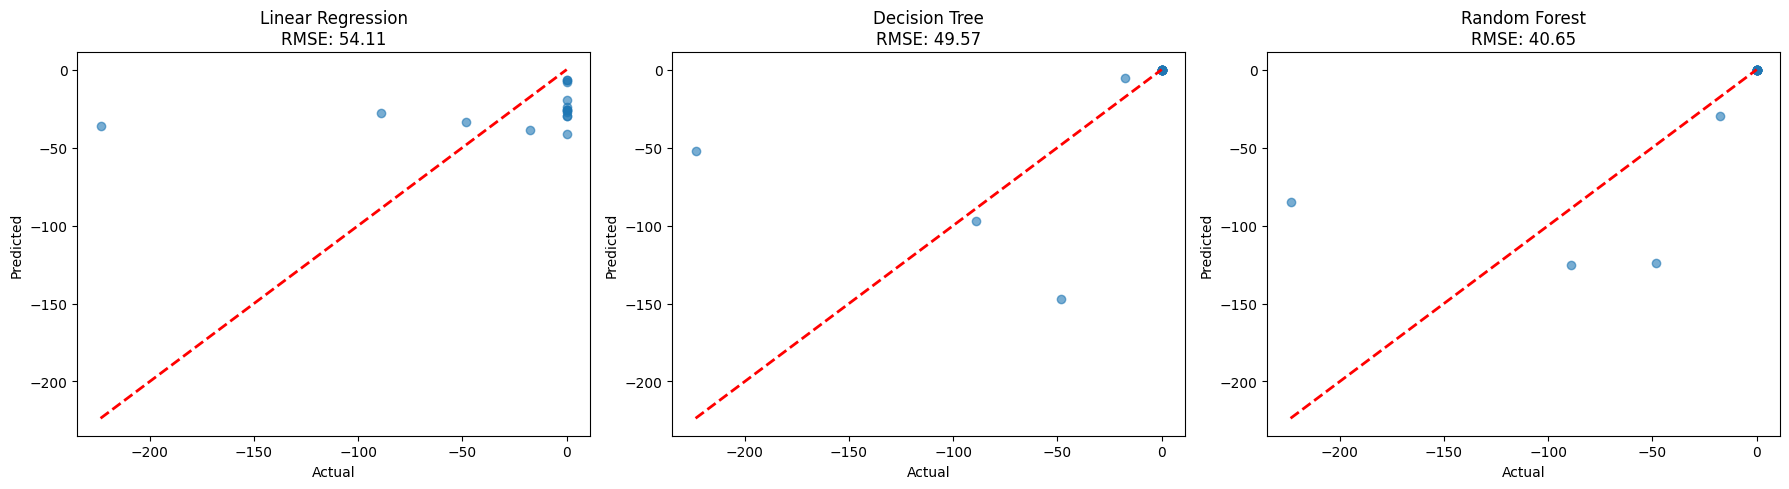

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=21),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    ax.scatter(y_test, preds, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nRMSE: {rmse:.2f}')

plt.tight_layout()
plt.show()

In the ideal case the plot would show all dots on the red diagonal line (y=x), meaning every prediction equals the actual value exactly.